# Visual AI Agent — Tool Calling 자동 질의응답

**Vision AI + LLM Agent**를 연계하여 **Tool Calling**으로 산업 매뉴얼 검색, Visual RAG, 센서 조회, MVTec 이력 조회를 자동 수행하고
**점검 보고서**를 생성하는 Agent 실습입니다.

> **선행 학습**: `02_conveyor_belt_visual_rag.ipynb` · `05_equipment_image_qa_practice.ipynb` · `06_mvtec_db_visual_intelligence.ipynb`

## 전체 흐름

```
사용자 질의 (텍스트 / 이미지+텍스트)
       ↓
Agent Orchestrator — Tool Calling 계획 (JSON schema)
       ↓
┌──────────────────────────────────────────────────────┐
│ search_manual        │ 산업 매뉴얼 키워드·벡터 검색   │
│ search_conveyor      │ SigLIP2 → ChromaDB 프레임 검색 │
│ get_sensor           │ sensor.csv 센서 수치 조회      │
│ analyze_visual       │ Qwen3-VL 시각 분석 (선택)      │
│ search_mvtec         │ SQLite MVTec 검사 이력 조회    │
│ search_past_analysis │ 과거 Qwen 분석 벡터 검색       │
└──────────────────────────────────────────────────────┘
       ↓
Tool 실행 결과(observation) 수집 → 종합 보고서 Markdown 생성
```

| Agent 구성 | 역할 |
|-----------|------|
| **Orchestrator** | 질의 분석 → 필요 Tool 선택·순서 결정 |
| **Tool Registry** | OpenAI function calling 형식 JSON schema |
| **Vision Tools** | SigLIP2 검색 + Qwen3-VL 분석 |
| **Knowledge Tools** | 산업 매뉴얼·MVTec DB·과거 분석 검색 |
| **Report Generator** | Tool 결과를 점검 보고서로 정리 |

### 모듈·데이터 참조

📄 **[00_모듈_참조.md](00_모듈_참조.md)**

| 구성요소 | 경로 |
|----------|------|
| Conveyor Visual RAG | `conveyor_analyze/conveyor_rag/` |
| MVTec 검사 DB | `mvtec_analyze/mvtec_rag/db.py` |
| 산업 매뉴얼 (이번 실습) | `data/agent/industrial_manual.json` |
| 생성 보고서 | `data/agent/reports/` |

## 0. 환경 설정

| 기술 | Agent 역할 |
|------|------------|
| **Tool Schema** | LLM이 호출할 함수 정의 (JSON) |
| **SigLIP2 + ChromaDB** | `search_conveyor` Visual RAG |
| **Qwen3-VL** | `analyze_visual` 시각 분석 (GPU 선택) |
| **SQLite** | `search_mvtec` 검사 이력 |
| **매뉴얼 JSON** | `search_manual` 지식베이스 |

**사전 준비**
<br>
1. `02` 노트북 — `data/conveyor/frames`, ChromaDB<br>
2. `06` 노트북 — `data/mvtec/inspections.db` (선택)<br>
3. `pip install -r conveyor_analyze/requirements.txt`<br>

> 매뉴얼 검색·프레임 검색·보고서 생성은 **GPU 없이** 실행 가능합니다. Qwen3-VL 분석은 `USE_QWEN=True`로 활성화하세요.

In [1]:
# !pip install -r conveyor_analyze/requirements.txt
# Conveyor Visual RAG — SigLIP2, ChromaDB, FastAPI, Qwen3-VL 등
# !pip install -r mvtec_analyze/requirements.txt
# MVTec AD 검사 — SQLite, ChromaDB, 결함 탐지 API 패키지


In [2]:
# --- 표준 라이브러리 ---
import json          # Tool schema·observation·보고서 JSON 직렬화
import re            # 매뉴얼 키워드 토큰 분리, LLM JSON 블록 추출
import sys           # conveyor_analyze / mvtec_analyze 경로 등록
from datetime import datetime, timezone  # 보고서 타임스탬프 (UTC)
from pathlib import Path
from typing import Any  # Tool arguments·observation 타입 힌트

# --- 서드파티 ---
import matplotlib.pyplot as plt  # search_conveyor 결과 썸네일 시각화
import pandas as pd              # 센서 CSV·Tool call 로그 테이블
from IPython.display import Markdown, display  # Agent 보고서 Markdown 렌더
from PIL import Image            # 프레임 이미지 로드·표시

# --- 프로젝트 루트·데이터 경로 ---
ROOT = Path(".").resolve()
CONVEYOR_DATA = ROOT / "data" / "conveyor"
FRAMES_DIR = CONVEYOR_DATA / "frames"       # 02 노트북 OpenCV 추출 JPG
CHROMA_DIR = CONVEYOR_DATA / "chroma_db"    # SigLIP2 프레임 벡터 DB
SENSOR_CSV = CONVEYOR_DATA / "sensor.csv"   # 프레임별 temp·rpm·vibration·status
MVTEC_DB = ROOT / "data" / "mvtec" / "inspections.db"  # 06 노트북 SQLite

# --- Agent 전용 경로 ---
AGENT_DIR = ROOT / "data" / "agent"
MANUAL_JSON = AGENT_DIR / "industrial_manual.json"  # 산업 매뉴얼 청크
REPORT_DIR = AGENT_DIR / "reports"                  # 생성 보고서 Markdown

# --- 패키지 import 경로 ---
CONVEYOR_ANALYZE = ROOT / "conveyor_analyze"
MVTEC_ANALYZE = ROOT / "mvtec_analyze"
sys.path.insert(0, str(CONVEYOR_ANALYZE))
sys.path.insert(0, str(MVTEC_ANALYZE))

from conveyor_rag.encoder import SigLIP2Encoder          # 텍스트·이미지 임베딩
from conveyor_rag.store import ChromaStore               # 프레임 ChromaDB 검색
from conveyor_rag.metadata_link import enrich_hits_with_sensor  # hit + sensor.csv 병합
from conveyor_rag.analysis_store import AnalysisVectorStore     # 과거 Qwen 분석 벡터
from conveyor_rag.sensor import get_sensor_by_frame, normalize_frame_name
from conveyor_rag.plot_utils import setup_korean_matplotlib

setup_korean_matplotlib()
AGENT_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

USE_QWEN = False  # True → Qwen3-VL analyze_visual 활성화 (GPU 권장)
TOP_K = 3         # 검색·매뉴얼 Top-k 기본값

# 선행 데이터 검증 — 02 노트북 미실행 시 조기 중단
if not FRAMES_DIR.exists() or not list(FRAMES_DIR.glob("frame*.jpg")):
    raise FileNotFoundError("02 노트북을 먼저 실행해 data/conveyor/frames 를 생성하세요.")

print(f"ROOT: {ROOT}")
print(f"프레임: {len(list(FRAMES_DIR.glob('frame*.jpg')))}장")
print(f"매뉴얼: {MANUAL_JSON.exists()}")
print(f"MVTec DB: {MVTEC_DB.exists()}")


ROOT: C:\MyCursorLab\09_Visual_RAG
프레임: 20장
매뉴얼: True
MVTec DB: True


## 1. Tool Schema 정의

LLM Agent가 호출할 **Tool**을 OpenAI function calling 형식 JSON schema로 정의합니다.
실무에서는 GPT·Qwen·Claude 등이 이 schema를 읽고 `tool_calls` JSON을 반환합니다.

In [3]:
# OpenAI function calling 형식 Tool schema 목록
# LLM(GPT·Qwen·Claude)은 이 schema를 읽고 tool_calls JSON을 반환함
TOOL_SCHEMAS: list[dict] = [
    {
        "type": "function",
        "function": {
            "name": "search_manual",
            "description": "산업 설비 매뉴얼·점검 절차·조치 가이드를 검색합니다.",
            "parameters": {
                "type": "object",
                "properties": {
                    "query": {"type": "string", "description": "검색 키워드 또는 질문"},
                    "top_k": {"type": "integer", "default": 3},
                },
                "required": ["query"],
            },
        },
    },
    {
        "type": "function",
        "function": {
            "name": "search_conveyor",
            "description": "텍스트 질의로 컨베이어 설비 프레임을 SigLIP2+ChromaDB에서 검색합니다.",
            "parameters": {
                "type": "object",
                "properties": {
                    "query": {"type": "string"},
                    "top_k": {"type": "integer", "default": 3},
                },
                "required": ["query"],
            },
        },
    },
    {
        "type": "function",
        "function": {
            "name": "get_sensor",
            "description": "특정 프레임의 temp·rpm·vibration·status 센서 수치를 조회합니다.",
            "parameters": {
                "type": "object",
                "properties": {
                    "frame": {"type": "string", "description": "예: frame0004"},
                },
                "required": ["frame"],
            },
        },
    },
    {
        "type": "function",
        "function": {
            "name": "analyze_visual",
            "description": "Qwen3-VL로 설비 이미지를 분석합니다 (GPU 필요).",
            "parameters": {
                "type": "object",
                "properties": {
                    "frame": {"type": "string"},
                    "question": {"type": "string"},
                },
                "required": ["frame", "question"],
            },
        },
    },
    {
        "type": "function",
        "function": {
            "name": "search_mvtec",
            "description": "MVTec AD 검사 이력(SQLite)에서 품목·불량 유형을 조회합니다.",
            "parameters": {
                "type": "object",
                "properties": {
                    "product": {"type": "string", "description": "품목명 (선택)"},
                    "label": {"type": "string", "enum": ["정상", "불량"], "description": "판정 (선택)"},
                    "limit": {"type": "integer", "default": 5},
                },
            },
        },
    },
    {
        "type": "function",
        "function": {
            "name": "search_past_analysis",
            "description": "과거 Qwen Visual RAG 분석 결과를 벡터 검색합니다.",
            "parameters": {
                "type": "object",
                "properties": {
                    "query": {"type": "string"},
                    "top_k": {"type": "integer", "default": 3},
                },
                "required": ["query"],
            },
        },
    },
]

# Planner·dispatch에서 Tool 이름 목록 참조용
tool_names = [t["function"]["name"] for t in TOOL_SCHEMAS]
print("등록 Tool:", ", ".join(tool_names))


등록 Tool: search_manual, search_conveyor, get_sensor, analyze_visual, search_mvtec, search_past_analysis


## 2. 산업 매뉴얼 지식베이스

`data/agent/industrial_manual.json`에 컨베이어 점검·MVTec 판정·보고서 양식 등 **매뉴얼 청크**를 저장합니다.
키워드 매칭 + (선택) SigLIP2 텍스트 임베딩으로 하이브리드 검색합니다.

In [4]:
class ManualStore:
    """산업 매뉴얼 JSON 청크 검색 — 키워드 + (선택) SigLIP2 의미 검색 하이브리드."""

    def __init__(self, path: Path, encoder: SigLIP2Encoder | None = None):
        self.chunks = json.loads(path.read_text(encoding="utf-8"))  # id·title·content·keywords
        self.encoder = encoder  # None이면 키워드 검색만
        self._embeddings: list[list[float]] | None = None  # 청크 임베딩 캐시

    def _keyword_score(self, query: str, chunk: dict) -> float:
        """질의 토큰이 청크 title·content·keywords에 등장하는 비율 (0~1)."""
        q = query.lower()
        text = f"{chunk['title']} {chunk['content']} {' '.join(chunk['keywords'])}".lower()
        hits = sum(1 for token in re.split(r"\W+", q) if len(token) >= 2 and token in text)
        return hits / max(len(re.split(r"\W+", q)), 1)

    def search(self, query: str, top_k: int = 3) -> list[dict]:
        scored = []
        for chunk in self.chunks:
            kw = self._keyword_score(query, chunk)
            sem = 0.0
            if self.encoder is not None:
                # 최초 1회: 전체 청크 임베딩 사전 계산 (반복 검색 가속)
                if self._embeddings is None:
                    texts = [f"{c['title']} {c['content']}" for c in self.chunks]
                    self._embeddings = self.encoder.encode_texts(texts)
                q_emb = self.encoder.encode_texts([query])[0]
                import numpy as np
                idx = self.chunks.index(chunk)
                c_emb = self._embeddings[idx]
                # 코사인 유사도 — L2 정규화된 SigLIP2 벡터 내적
                sem = float(np.dot(q_emb, c_emb) / (np.linalg.norm(q_emb) * np.linalg.norm(c_emb) + 1e-8))
            score = 0.6 * kw + 0.4 * sem  # 키워드 60% + 의미 40% 가중 합산
            scored.append({"score": score, **chunk})
        scored.sort(key=lambda x: x["score"], reverse=True)
        return scored[:top_k]


# 전역 SigLIP2 인코더 — ChromaDB·매뉴얼·Agent Tool 공유
encoder = SigLIP2Encoder()
manual_store = ManualStore(MANUAL_JSON, encoder=encoder)

# 매뉴얼 검색 동작 확인
demo_hits = manual_store.search("벨트 Fault 긴급 조치", top_k=2)
for h in demo_hits:
    print(f"[{h['id']}] {h['title']} (score={h['score']:.2f})")
    print(f"  → {h['content'][:80]}...")


[transformers] Model config: bos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49406. This may result in unexpected behavior.
[transformers] Model config: eos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49407. This may result in unexpected behavior.
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/888 [00:00<?, ?it/s]

[conv-003] 벨트 Fault 긴급 조치 (score=0.94)
  → status=Fault 또는 벨트 표면 파열·심한 마모가 확인되면 즉시 라인 정지 후 LO/TO(Lock-Out/Tag-Out)를 수행한다. 손...
[conv-002] 벨트 이상 징후 — Warning 상태 (score=0.50)
  → 센서 status가 Warning일 때: (1) 벨트 텐션 불균형, (2) 베어링 마모 초기, (3) 이물질 끼임 가능성을 의심한다. temp ...


## 3. Agent Tool 구현

각 Tool schema에 대응하는 **실행 함수**를 `ToolBox` 클래스로 묶습니다.
기존 `conveyor_rag`·`mvtec_rag` 모듈을 Agent Tool로 래핑합니다.

In [5]:
# TOOL_SCHEMAS의 각 name에 대응하는 실행 함수를 하나의 클래스로 묶음
# Agent Orchestrator는 dispatch(name, arguments)로 Tool을 호출
class ToolBox:
    """Visual AI Agent가 호출하는 Tool 실행기."""

    def __init__(self, encoder: SigLIP2Encoder, use_qwen: bool = False):
        self.encoder = encoder
        self.chroma = ChromaStore()                              # 프레임 ChromaDB
        self.manual = ManualStore(MANUAL_JSON, encoder=encoder)  # 산업 매뉴얼 KB
        self.analysis_store = AnalysisVectorStore()              # 과거 Qwen 분석 벡터
        self.use_qwen = use_qwen                                 # Qwen3-VL analyze_visual on/off
        self._qwen = None       # lazy load — GPU 메모리 절약
        self._mvtec_db = None   # lazy load — 06 노트북 SQLite

    def _get_qwen(self):
        """Qwen3-VL 분석기 최초 1회 로드."""
        if self._qwen is None:
            from conveyor_rag.analyzer import QwenAnalyzer
            self._qwen = QwenAnalyzer()
        return self._qwen

    def _get_mvtec_db(self):
        """MVTec InspectionDB — inspections.db 존재 시에만 연결."""
        if self._mvtec_db is None and MVTEC_DB.exists():
            from mvtec_rag.db import InspectionDB
            self._mvtec_db = InspectionDB(MVTEC_DB)
        return self._mvtec_db

    def search_manual(self, query: str, top_k: int = 3) -> dict:
        """Tool: search_manual — industrial_manual.json 하이브리드 검색."""
        hits = self.manual.search(query, top_k=top_k)
        return {"tool": "search_manual", "query": query, "results": hits}

    def search_conveyor(self, query: str, top_k: int = 3) -> dict:
        """Tool: search_conveyor — SigLIP2 텍스트 임베딩 → ChromaDB Top-k."""
        emb = self.encoder.encode_texts([query])[0].tolist()
        hits = self.chroma.search(emb, top_k=top_k)
        hits = enrich_hits_with_sensor(hits, SENSOR_CSV)  # sensor.csv 병합
        compact = []
        for h in hits:
            meta = h["metadata"]
            sensor = h.get("sensor", {})
            # Agent·보고서용 경량 dict — metadata 전체 대신 핵심 필드만
            compact.append({
                "frame": meta.get("frame"),
                "similarity": round(h["similarity"], 3),
                "status": sensor.get("status"),
                "temp": sensor.get("temp"),
                "path": meta.get("local_path"),
            })
        return {"tool": "search_conveyor", "query": query, "results": compact}

    def get_sensor(self, frame: str) -> dict:
        """Tool: get_sensor — sensor.csv 단일 프레임 조회."""
        row = get_sensor_by_frame(frame, SENSOR_CSV)
        return {"tool": "get_sensor", "frame": frame, "sensor": row}

    def analyze_visual(self, frame: str, question: str) -> dict:
        """Tool: analyze_visual — Qwen3-VL 이미지+센서 교차 분석 (USE_QWEN=True)."""
        # frame0004 / frame0004.jpg 모두 지원 (sensor.normalize_frame_name)
        path = FRAMES_DIR / normalize_frame_name(frame)
        if not path.exists():
            return {"tool": "analyze_visual", "error": f"프레임 없음: {frame}"}
        if not self.use_qwen:
            # GPU 없거나 USE_QWEN=False — 센서 수치만 observation으로 반환
            sensor = get_sensor_by_frame(frame, SENSOR_CSV)
            return {
                "tool": "analyze_visual",
                "frame": frame,
                "skipped": True,
                "message": "USE_QWEN=False — 센서 수치만 반환",
                "sensor": sensor,
            }
        qwen = self._get_qwen()
        sensor = get_sensor_by_frame(frame, SENSOR_CSV)
        # VLM 프롬프트에 센서 수치 포함 — Visual RAG 교차 검증
        prompt = (
            f"{question}\n\n"
            f"[센서] temp={sensor['temp']}°C, rpm={sensor['rpm']}, "
            f"vibration={sensor['vibration']}, status={sensor['status']}"
        )
        analysis = qwen.run_vl([str(path)], prompt, max_new_tokens=150)
        return {"tool": "analyze_visual", "frame": frame, "analysis": analysis, "sensor": sensor}

    def search_mvtec(self, product: str | None = None, label: str | None = None, limit: int = 5) -> dict:
        """Tool: search_mvtec — SQLite inspections 테이블 필터 조회."""
        db = self._get_mvtec_db()
        if db is None:
            return {"tool": "search_mvtec", "error": "06 노트북으로 inspections.db를 먼저 생성하세요."}
        rows = db.query(product=product, label=label, limit=limit)
        compact = [
            {
                "id": r["id"], "product": r["product"],
                "defect_type": r["defect_type"], "label": r["label"],
                "confidence": r.get("confidence"),
            }
            for r in rows
        ]
        return {"tool": "search_mvtec", "count": len(compact), "results": compact}

    def search_past_analysis(self, query: str, top_k: int = 3) -> dict:
        """Tool: search_past_analysis — ChromaDB conveyor_analysis_results 벡터 검색."""
        hits = self.analysis_store.search(self.encoder, query, top_k=top_k)
        return {"tool": "search_past_analysis", "query": query, "results": hits}

    def dispatch(self, name: str, arguments: dict) -> dict:
        """Tool name + arguments → 실행 결과."""
        fn = getattr(self, name, None)
        if fn is None:
            return {"error": f"Unknown tool: {name}"}
        return fn(**arguments)


toolbox = ToolBox(encoder, use_qwen=USE_QWEN)
print("ToolBox 준비 완료")


ToolBox 준비 완료


## 4. Agent Orchestrator — Tool Calling 루프

1. **Plan**: 사용자 질의 → 호출할 Tool 목록 결정
2. **Act**: 각 Tool 실행 → observation 수집
3. **Report**: observation을 종합해 Markdown 보고서 생성

실무 LLM Agent는 Plan 단계에서 `TOOL_SCHEMAS`를 system prompt에 넣고
모델이 `{name, arguments}` JSON을 반환합니다. 여기서는 **키워드 기반 Planner**로 동일 프로토콜을 시연합니다.

In [6]:
# 키워드 Planner 규칙 — (트리거 키워드 목록, Tool name, 기본 arguments)
# LLM API 없이 교육용으로 동일 tool_calls 프로토콜을 시뮬레이션
PLAN_RULES: list[tuple[list[str], str, dict]] = [
    (["매뉴얼", "점검", "조치", "절차", "가이드", "원인"], "search_manual", {}),
    (["벨트", "컨베이어", "프레임", "설비", "이상"], "search_conveyor", {}),
    (["센서", "온도", "rpm", "진동", "vibration"], "get_sensor", {}),
    (["분석", "이미지", "시각", "손상", "파열"], "analyze_visual", {}),
    (["mvtec", "불량", "결함", "검사", "품목", "defect"], "search_mvtec", {}),
    (["과거", "이력", "분석결과", "previous"], "search_past_analysis", {}),
]


def plan_tools(user_query: str, frame_hint: str | None = None) -> list[dict]:
    """질의 키워드 → Tool call 목록 (LLM tool_calls 형식)."""
    q_lower = user_query.lower()
    calls: list[dict] = []
    seen: set[str] = set()  # 동일 Tool 중복 호출 방지

    for keywords, tool_name, extra_args in PLAN_RULES:
        if any(kw in user_query or kw.lower() in q_lower for kw in keywords):
            if tool_name in seen:
                continue
            seen.add(tool_name)
            args: dict[str, Any] = dict(extra_args)
            # Tool별 arguments 자동 채움
            if tool_name in ("search_manual", "search_conveyor", "search_past_analysis"):
                args["query"] = user_query
                args["top_k"] = TOP_K
            elif tool_name == "get_sensor" and frame_hint:
                args["frame"] = frame_hint
            elif tool_name == "analyze_visual" and frame_hint:
                args["frame"] = frame_hint
                args["question"] = user_query
            elif tool_name == "search_mvtec":
                if "불량" in user_query:
                    args["label"] = "불량"
                for prod in ["bottle", "cable", "screw", "pill", "tile"]:
                    if prod in q_lower:
                        args["product"] = prod
                        break
                args["limit"] = 5
            calls.append({"name": tool_name, "arguments": args})

    # 어떤 키워드도 매칭되지 않으면 매뉴얼+프레임 검색 기본 실행
    if not calls:
        calls = [
            {"name": "search_manual", "arguments": {"query": user_query, "top_k": TOP_K}},
            {"name": "search_conveyor", "arguments": {"query": user_query, "top_k": TOP_K}},
        ]
    return calls


def generate_report(user_query: str, observations: list[dict]) -> str:
    """Tool observation → Markdown 점검 보고서."""
    ts = datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M UTC")
    lines = [
        f"# Visual AI Agent 점검 보고서",
        f"",
        f"- **생성 시각**: {ts}",
        f"- **질의**: {user_query}",
        f"",
    ]

    # observation 유형별 수집 버퍼
    manual_refs = []
    visual_summary = []
    sensor_rows = []
    mvtec_rows = []
    actions = []

    for obs in observations:
        tool = obs.get("tool", "")
        if tool == "search_manual":
            for r in obs.get("results", []):
                manual_refs.append(f"- **[{r['id']}] {r['title']}**: {r['content']}")
                if "Fault" in r.get("title", "") or "긴급" in r.get("title", ""):
                    actions.append("긴급: 라인 정지 및 LO/TO 수행 (매뉴얼 conv-003)")
        elif tool == "search_conveyor":
            for r in obs.get("results", []):
                visual_summary.append(
                    f"- `{r['frame']}` sim={r['similarity']} status={r['status']} temp={r.get('temp')}°C"
                )
                if r.get("status") == "Fault":
                    actions.append(f"{r['frame']}: Fault 상태 — 즉시 점검 필요")
                elif r.get("status") == "Warning":
                    actions.append(f"{r['frame']}: Warning — 30분 내 재점검")
        elif tool == "get_sensor":
            s = obs.get("sensor", {})
            if s:
                sensor_rows.append(
                    f"- `{obs.get('frame')}`: temp={s.get('temp')}°C, rpm={s.get('rpm')}, "
                    f"vibration={s.get('vibration')}, status={s.get('status')}"
                )
        elif tool == "analyze_visual":
            if obs.get("analysis"):
                visual_summary.append(f"- **VLM 분석** ({obs.get('frame')}): {obs['analysis']}")
        elif tool == "search_mvtec":
            for r in obs.get("results", []):
                mvtec_rows.append(
                    f"- id={r['id']} {r['product']}/{r['defect_type']} → {r['label']}"
                )
        # --- HTTP Tool observation (FastAPI 래핑) ---
        elif tool == "api_conveyor_search":
            for r in obs.get("data", {}).get("results", obs.get("results", [])):
                meta = r.get("metadata", r)
                sensor = r.get("sensor", meta)
                frame = meta.get("frame", r.get("frame", "?"))
                sim = r.get("similarity", 0)
                status = sensor.get("status", r.get("status", "?"))
                src = obs.get("source", obs.get("fallback", "http"))
                visual_summary.append(f"- `{frame}` sim={sim:.3f} status={status} [{src}]")
        elif tool == "api_conveyor_analyze":
            data = obs.get("data", {})
            if data.get("analysis"):
                visual_summary.append(f"- **API Visual RAG**: {data['analysis'][:300]}")
        elif tool == "api_mvtec_stats":
            data = obs.get("data", {})
            if isinstance(data, dict) and not obs.get("fallback"):
                mvtec_rows.append(f"- **통계**: {json.dumps(data, ensure_ascii=False)[:300]}")
            elif isinstance(data, dict) and data.get("results"):
                for r in data["results"]:
                    mvtec_rows.append(f"- id={r.get('id')} {r.get('product')} → {r.get('label')} [fallback]")
        elif tool == "api_mvtec_search":
            for r in obs.get("data", {}).get("hits", obs.get("data", {}).get("results", [])):
                meta = r.get("metadata", r)
                mvtec_rows.append(
                    f"- {meta.get('product', '?')}/{meta.get('defect_type', '?')} sim={r.get('similarity', 0):.3f} [HTTP]"
                )

    lines.append("## 1. 매뉴얼 근거")
    lines.extend(manual_refs or ["- (해당 매뉴얼 없음)"])
    lines.append("")
    lines.append("## 2. 시각·센서 분석")
    lines.extend(visual_summary or ["- (시각 검색 결과 없음)"])
    lines.extend(sensor_rows)
    lines.append("")
    if mvtec_rows:
        lines.append("## 3. MVTec 검사 이력")
        lines.extend(mvtec_rows)
        lines.append("")
    lines.append("## 4. 권장 조치")
    unique_actions = list(dict.fromkeys(actions))  # 순서 유지 중복 제거
    if unique_actions:
        lines.extend(f"- {a}" for a in unique_actions)
    else:
        lines.append("- 특이사항 없음 — 정상 가동 유지")
    lines.append("")
    lines.append("---")
    lines.append("*Visual AI Agent — Tool Calling 자동 생성*")
    return "\n".join(lines)


class VisualAIAgent:
    """Vision AI + LLM Agent Tool Calling 루프 — Plan → Act → Report."""

    def __init__(self, toolbox: ToolBox):
        self.toolbox = toolbox

    def run(self, user_query: str, frame_hint: str | None = None, verbose: bool = True) -> dict:
        # Qwen 실행 후 unload된 SigLIP2 자동 재로드
        self.toolbox.encoder._ensure_loaded()
        plan = plan_tools(user_query, frame_hint=frame_hint)
        if verbose:
            print(f"[Plan] {len(plan)}개 Tool 호출 예정:")
            for step in plan:
                print(f"  → {step['name']}({json.dumps(step['arguments'], ensure_ascii=False)})")

        observations = []
        for step in plan:
            # get_sensor / analyze_visual 은 frame_hint 필요 — search_conveyor 결과에서 보충
            args = dict(step["arguments"])
            if step["name"] in ("get_sensor", "analyze_visual") and "frame" not in args:
                conv = next((o for o in observations if o.get("tool") == "search_conveyor"), None)
                if conv and conv.get("results"):
                    args["frame"] = conv["results"][0]["frame"]
                    if step["name"] == "analyze_visual":
                        args["question"] = user_query
            result = self.toolbox.dispatch(step["name"], args)
            observations.append(result)
            if verbose:
                print(f"[Done] {step['name']}")

        report = generate_report(user_query, observations)
        return {"query": user_query, "plan": plan, "observations": observations, "report": report}

    def save_report(self, result: dict) -> Path:
        """Markdown 보고서를 data/agent/reports/ 에 저장."""
        ts = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S")
        path = REPORT_DIR / f"report_{ts}.md"
        path.write_text(result["report"], encoding="utf-8")
        return path


agent = VisualAIAgent(toolbox)
print("VisualAIAgent 준비 완료")


VisualAIAgent 준비 완료


## 5. 시나리오 1 — 컨베이어 이상 질의 (Tool Calling 자동 Q&A)

현장 엔지니어 질의: *"컨베이어 벨트 Fault 상태 원인과 긴급 조치는?"*

Agent가 매뉴얼 검색 → 프레임 검색 → 센서 조회를 **자동으로** 수행합니다.

In [7]:
# 시나리오 1: 컨베이어 Fault 긴급 조치 — Agent End-to-End 실행
QUERY_1 = "컨베이어 벨트 Fault 상태 원인과 긴급 조치 절차를 알려주세요"

result_1 = agent.run(QUERY_1)  # plan → dispatch → generate_report
display(Markdown(result_1["report"]))

report_path_1 = agent.save_report(result_1)
print(f"\n보고서 저장: {report_path_1}")


[Plan] 2개 Tool 호출 예정:
  → search_manual({"query": "컨베이어 벨트 Fault 상태 원인과 긴급 조치 절차를 알려주세요", "top_k": 3})
  → search_conveyor({"query": "컨베이어 벨트 Fault 상태 원인과 긴급 조치 절차를 알려주세요", "top_k": 3})
[Done] search_manual
[Done] search_conveyor


# Visual AI Agent 점검 보고서

- **생성 시각**: 2026-07-04 13:44 UTC
- **질의**: 컨베이어 벨트 Fault 상태 원인과 긴급 조치 절차를 알려주세요

## 1. 매뉴얼 근거
- **[conv-003] 벨트 Fault 긴급 조치**: status=Fault 또는 벨트 표면 파열·심한 마모가 확인되면 즉시 라인 정지 후 LO/TO(Lock-Out/Tag-Out)를 수행한다. 손상 구간 50cm 이상이면 벨트 교체, 미만이면 응급 패치 후 24시간 내 교체 예약.
- **[conv-001] 컨베이어 벨트 일상 점검**: 컨베이어 벨트는 가동 전·후 육안 점검을 실시한다. 벨트 표면의 균열·찢김·이물질 부착 여부를 확인하고, 롤러·텐션 장치의 이상 소음을 청취한다. 점검 주기: 1교대(8시간) 1회.
- **[conv-002] 벨트 이상 징후 — Warning 상태**: 센서 status가 Warning일 때: (1) 벨트 텐션 불균형, (2) 베어링 마모 초기, (3) 이물질 끼임 가능성을 의심한다. temp 45°C 초과 또는 vibration 0.5 초과 시 속도를 20% 감속하고 30분 내 재점검한다.

## 2. 시각·센서 분석
- `frame0006.jpg` sim=0.114 status=Fault temp=49.9°C
- `frame0003.jpg` sim=0.109 status=Warning temp=45.3°C
- `frame0019.jpg` sim=0.109 status=Warning temp=54.9°C

## 4. 권장 조치
- 긴급: 라인 정지 및 LO/TO 수행 (매뉴얼 conv-003)
- frame0006.jpg: Fault 상태 — 즉시 점검 필요
- frame0003.jpg: Warning — 30분 내 재점검
- frame0019.jpg: Warning — 30분 내 재점검

---
*Visual AI Agent — Tool Calling 자동 생성*


보고서 저장: C:\MyCursorLab\09_Visual_RAG\data\agent\reports\report_20260704_134457.md


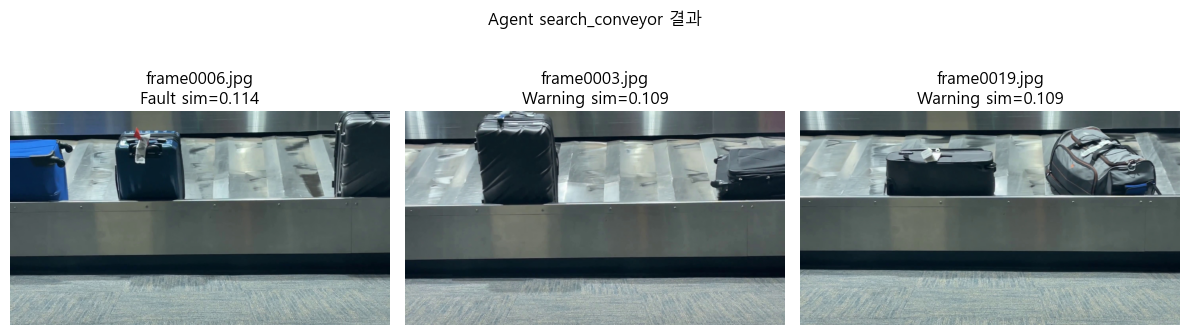

In [8]:
# search_conveyor Tool 결과를 matplotlib 썸네일로 시각화
conv_obs = next(o for o in result_1["observations"] if o["tool"] == "search_conveyor")
hits = conv_obs["results"]

n = min(len(hits), 3)
if n:
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    if n == 1:
        axes = [axes]
    for i, h in enumerate(hits[:n]):
        path = h.get("path", "")
        if Path(path).exists():
            axes[i].imshow(Image.open(path))
        axes[i].set_title(f"{h['frame']}\n{h['status']} sim={h['similarity']}")
        axes[i].axis("off")
    plt.suptitle("Agent search_conveyor 결과")
    plt.tight_layout()
    plt.show()


## 6. 시나리오 2 — MVTec 불량 + 매뉴얼 통합 질의

품질 담당자 질의: *"cable 품목 불량 이력과 scratch 결함 대응 매뉴얼"*

In [9]:
# 시나리오 2: MVTec cable 불량 + scratch 매뉴얼 — 다중 Tool 연계
QUERY_2 = "cable 품목 불량 검사 이력과 scratch 결함 대응 매뉴얼을 조회해줘"

result_2 = agent.run(QUERY_2)
display(Markdown(result_2["report"]))

# Tool call 로그 테이블
plan_df = pd.DataFrame([
    {"step": i + 1, "tool": s["name"], "arguments": json.dumps(s["arguments"], ensure_ascii=False)}
    for i, s in enumerate(result_2["plan"])
])
display(plan_df)


[Plan] 3개 Tool 호출 예정:
  → search_manual({"query": "cable 품목 불량 검사 이력과 scratch 결함 대응 매뉴얼을 조회해줘", "top_k": 3})
  → search_mvtec({"label": "불량", "product": "cable", "limit": 5})
  → search_past_analysis({"query": "cable 품목 불량 검사 이력과 scratch 결함 대응 매뉴얼을 조회해줘", "top_k": 3})
[Done] search_manual
[Done] search_mvtec
[Done] search_past_analysis


# Visual AI Agent 점검 보고서

- **생성 시각**: 2026-07-04 13:44 UTC
- **질의**: cable 품목 불량 검사 이력과 scratch 결함 대응 매뉴얼을 조회해줘

## 1. 매뉴얼 근거
- **[mvtec-002] 결함 유형별 대응 — scratch·crack**: scratch(긁힘): 표면 연마 또는 재가공 후 재검사. crack(균열): 즉시 불량 처리, 원자재 LOT 격리. 유사 이력은 inspections DB에서 defect_type 필터로 조회한다.
- **[mvtec-001] MVTec AD 1차 AI 판정 (SigLIP2)**: 업로드 이미지는 SigLIP2로 good/defect 1차 분류한다. confidence 0.7 미만이면 Qwen3-VL 2차 분석을 수행한다. 품목(product)별 임계값은 bottle 0.75, cable 0.70, screw 0.72를 기본값으로 사용한다.
- **[mvtec-003] 불량률 통계·보고**: 주간 품질 보고서에는 품목별 불량률, 주요 defect_type Top-3, AI confidence 평균을 포함한다. SQL: SELECT product, label, COUNT(*) FROM inspections GROUP BY product, label.

## 2. 시각·센서 분석
- (시각 검색 결과 없음)

## 3. MVTec 검사 이력
- id=35 cable/poke_insulation → 불량
- id=34 cable/poke_insulation → 불량
- id=33 cable/missing_wire → 불량
- id=32 cable/missing_wire → 불량
- id=31 cable/missing_cable → 불량

## 4. 권장 조치
- 특이사항 없음 — 정상 가동 유지

---
*Visual AI Agent — Tool Calling 자동 생성*

,step,tool,arguments
0,1,search_manual,"{""query"": ""cable 품목 불량 검사 이력과 scratch 결함 대응 매뉴..."
1,2,search_mvtec,"{""label"": ""불량"", ""product"": ""cable"", ""limit"": 5}"
2,3,search_past_analysis,"{""query"": ""cable 품목 불량 검사 이력과 scratch 결함 대응 매뉴..."


## 7. 시나리오 3 — 특정 프레임 Visual RAG + 보고서

프레임을 지정하면 `analyze_visual` Tool이 Qwen3-VL 분석을 수행합니다 (`USE_QWEN=True` 필요).

In [10]:
# Fault 프레임 자동 탐색 — sensor.csv status=Fault 중 첫 프레임을 frame_hint로 사용
sensor_df = pd.read_csv(SENSOR_CSV)
fault_frames = sensor_df[sensor_df["status"] == "Fault"]["frame"].tolist()
frame_hint = fault_frames[0] if fault_frames else "frame0001"
print(f"대상 프레임: {frame_hint} (status=Fault)")

QUERY_3 = f"{frame_hint} 프레임의 벨트 손상 여부를 분석하고 센서와 교차 검증해줘"
result_3 = agent.run(QUERY_3, frame_hint=frame_hint)
display(Markdown(result_3["report"]))

report_path_3 = agent.save_report(result_3)
print(f"보고서 저장: {report_path_3}")


대상 프레임: frame0004.jpg (status=Fault)
[Plan] 3개 Tool 호출 예정:
  → search_conveyor({"query": "frame0004.jpg 프레임의 벨트 손상 여부를 분석하고 센서와 교차 검증해줘", "top_k": 3})
  → get_sensor({"frame": "frame0004.jpg"})
  → analyze_visual({"frame": "frame0004.jpg", "question": "frame0004.jpg 프레임의 벨트 손상 여부를 분석하고 센서와 교차 검증해줘"})
[Done] search_conveyor
[Done] get_sensor
[Done] analyze_visual


# Visual AI Agent 점검 보고서

- **생성 시각**: 2026-07-04 13:44 UTC
- **질의**: frame0004.jpg 프레임의 벨트 손상 여부를 분석하고 센서와 교차 검증해줘

## 1. 매뉴얼 근거
- (해당 매뉴얼 없음)

## 2. 시각·센서 분석
- `frame0001.jpg` sim=0.116 status=Normal temp=38.2°C
- `frame0004.jpg` sim=0.111 status=Fault temp=48.8°C
- `frame0003.jpg` sim=0.111 status=Warning temp=45.3°C
- `frame0004.jpg`: temp=48.8°C, rpm=1260, vibration=0.45, status=Fault

## 4. 권장 조치
- frame0004.jpg: Fault 상태 — 즉시 점검 필요
- frame0003.jpg: Warning — 30분 내 재점검

---
*Visual AI Agent — Tool Calling 자동 생성*

보고서 저장: C:\MyCursorLab\09_Visual_RAG\data\agent\reports\report_20260704_134458.md


## 8. LLM Tool Calling 프로토콜 (실무 연동 참고)

실무에서는 아래와 같이 LLM API에 `tools=TOOL_SCHEMAS`를 전달합니다.
노트북의 `plan_tools()`는 동일 프로토콜을 **키워드 Planner**로 대체한 교육용 구현입니다.

In [11]:
# 실무 LLM API 연동 시 요청·응답 프로토콜 예시 (교육용 JSON)
LLM_TOOL_CALL_EXAMPLE = {
    "model": "gpt-4o / Qwen3-VL / Claude",
    "messages": [
        {
            "role": "system",
            "content": (
                "당신은 산업 설비 Visual AI Agent입니다. "
                "사용자 질의에 답하기 위해 제공된 Tool을 호출하세요."
            ),
        },
        {"role": "user", "content": "컨베이어 Fault 긴급 조치 알려줘"},
    ],
    "tools": TOOL_SCHEMAS,
    "expected_tool_calls": [
        {"name": "search_manual", "arguments": {"query": "Fault 긴급 조치", "top_k": 3}},
        {"name": "search_conveyor", "arguments": {"query": "컨베이어 Fault", "top_k": 3}},
    ],
}

print(json.dumps(LLM_TOOL_CALL_EXAMPLE, indent=2, ensure_ascii=False))


{
  "model": "gpt-4o / Qwen3-VL / Claude",
  "messages": [
    {
      "role": "system",
      "content": "당신은 산업 설비 Visual AI Agent입니다. 사용자 질의에 답하기 위해 제공된 Tool을 호출하세요."
    },
    {
      "role": "user",
      "content": "컨베이어 Fault 긴급 조치 알려줘"
    }
  ],
  "tools": [
    {
      "type": "function",
      "function": {
        "name": "search_manual",
        "description": "산업 설비 매뉴얼·점검 절차·조치 가이드를 검색합니다.",
        "parameters": {
          "type": "object",
          "properties": {
            "query": {
              "type": "string",
              "description": "검색 키워드 또는 질문"
            },
            "top_k": {
              "type": "integer",
              "default": 3
            }
          },
          "required": [
            "query"
          ]
        }
      }
    },
    {
      "type": "function",
      "function": {
        "name": "search_conveyor",
        "description": "텍스트 질의로 컨베이어 설비 프레임을 SigLIP2+ChromaDB에서 검색합니다.",
        "parameters": {
          "type": "obj

## 9. 정리 (기본 Agent)

| 학습 내용 | 구현 |
|----------|------|
| **Vision AI + Agent** | SigLIP2·Qwen3-VL을 Tool로 래핑 |
| **Tool Calling** | JSON schema → plan → dispatch → observation |
| **매뉴얼 검색** | `industrial_manual.json` 하이브리드 검색 |
| **보고서 생성** | observation → Markdown → `data/agent/reports/` |

아래 **10~13절**에서 정리에 언급한 확장 단계를 이어서 실습합니다.

## 10. 확장 1 — Qwen3-VL `analyze_visual` Tool 활성화

`USE_QWEN=True`로 설정하면 Agent의 `analyze_visual` Tool이 **Qwen3-VL**로 설비 이미지를 분석합니다.
12GB VRAM 환경에서는 SigLIP2와 동시 상주가 어려우므로, 분석 전후 GPU 캐시를 비웁니다.

> GPU·모델 로딩 시간이 길 수 있습니다. Colab T4 / 로컬 CUDA 권장.

분석 대상: frame0004.jpg


Loading weights:   0%|          | 0/625 [00:00<?, ?it/s]

[Qwen3-VL] frame0004.jpg
이미지를 분석한 결과, 이는 **컨베이어 벨트의 상태가 이상**이며, 다음과 같은 문제점이 있습니다:

- **손상 및 이상 징후**:  
  - `status=Fault` (장치 오류)라는 정보로 보아 현재 시스템은 기능하지 않거나 문제가 발생하고 있음을 알 수 있습니다.
  - `vibration=0.45` (진동 값)이 높은 수준으로 나타나며, 일반적으로 정상적인 진동값보다 훨씬 높습니다. 이는 구조적 부하 또는 마찰 등에 의해 발생할 가능성이 큽니다.
  - `


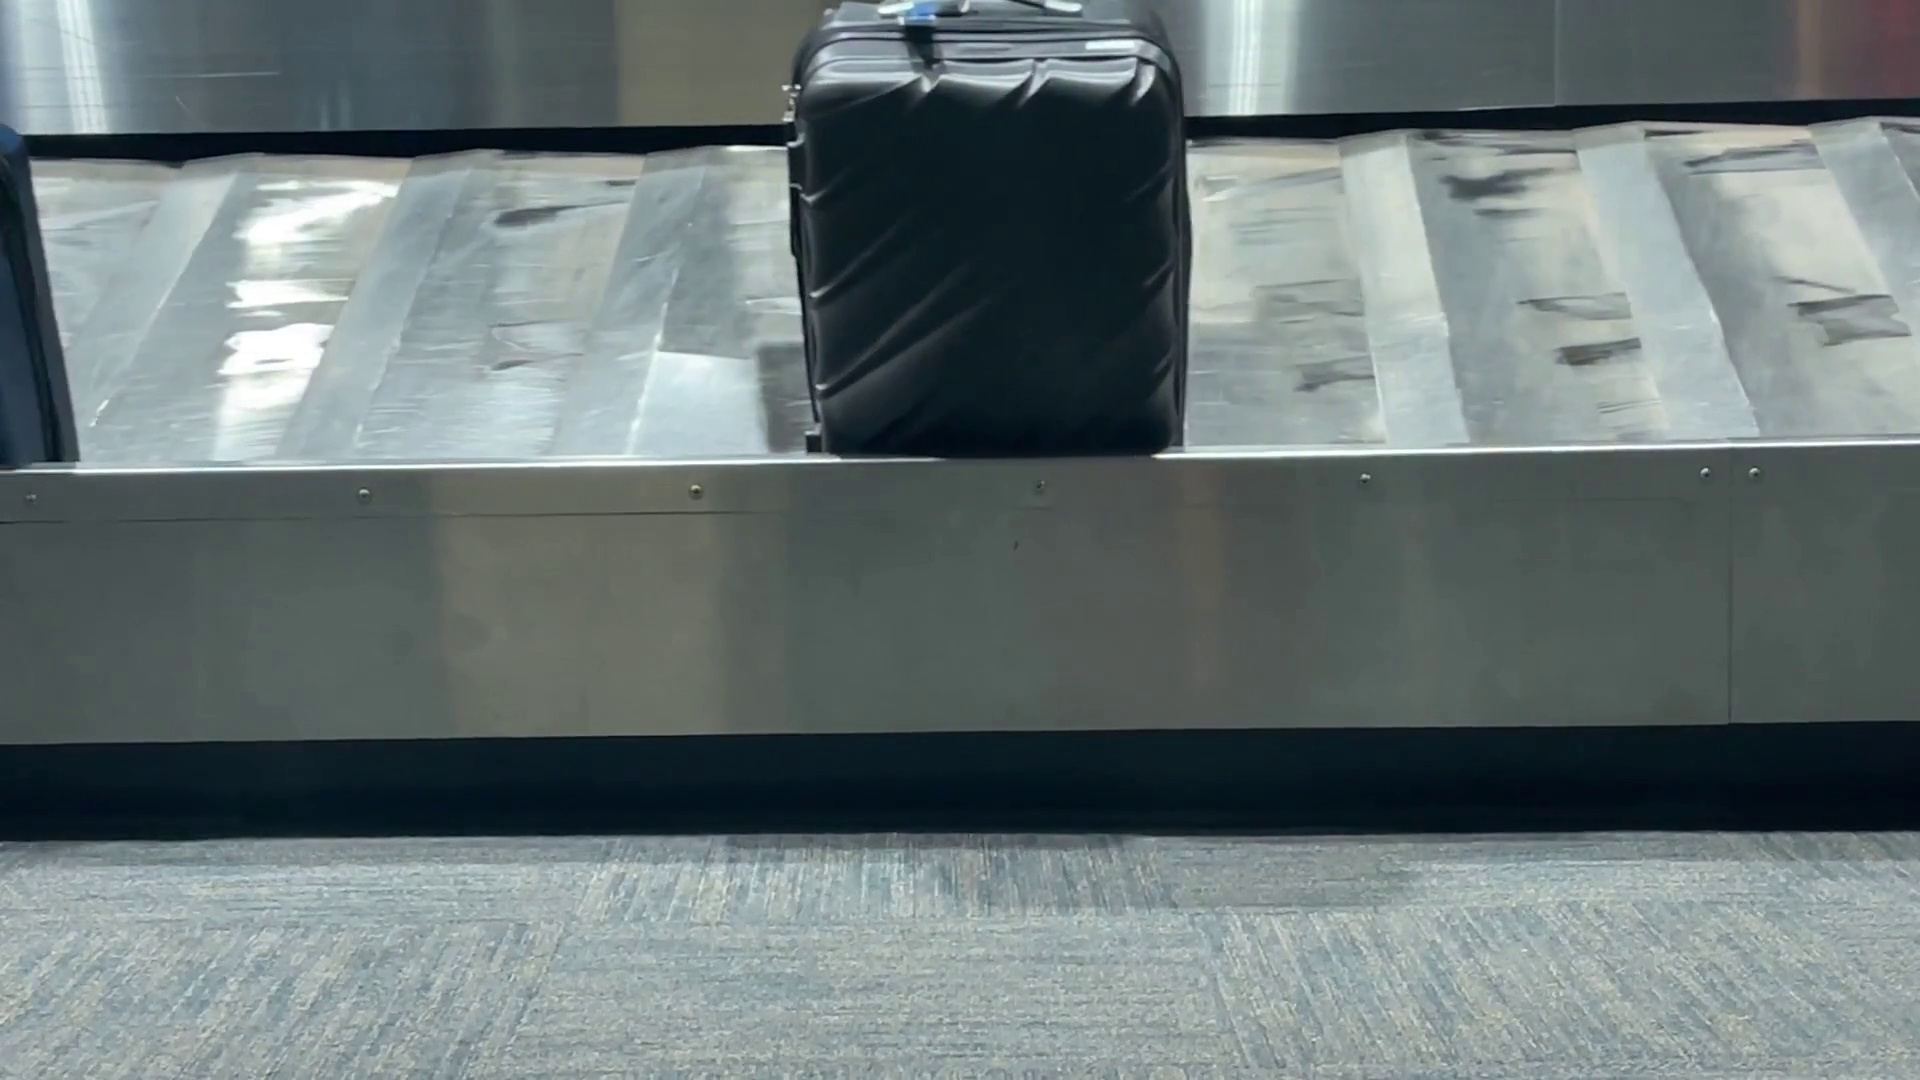

Loading weights:   0%|          | 0/888 [00:00<?, ?it/s]

SigLIP2 재로드 완료 — LLM Planner 실행 가능


In [12]:
import torch

# Qwen3-VL analyze_visual Tool 활성화
USE_QWEN = True  # Qwen3-VL analyze_visual 활성화
toolbox_qwen = ToolBox(encoder, use_qwen=USE_QWEN)
agent_qwen = VisualAIAgent(toolbox_qwen)

# Fault 프레임 선택 — sensor.csv에서 status=Fault인 첫 행
sensor_df = pd.read_csv(SENSOR_CSV)
fault_frames = sensor_df[sensor_df["status"] == "Fault"]["frame"].tolist()
target_frame = fault_frames[0] if fault_frames else "frame0001"
print(f"분석 대상: {target_frame}")

# 12GB VRAM: SigLIP2·Qwen 동시 상주 불가 → 분석 전 SigLIP2 GPU 해제
if torch.cuda.is_available():
    encoder.unload()  # SigLIP2 VRAM 해제 → Qwen 로딩 여유 확보
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

# analyze_visual Tool 직접 호출 (Agent 루프 없이 VLM 단독 테스트)
vlm_result = toolbox_qwen.analyze_visual(
    frame=target_frame,
    question="이 컨베이어 벨트 이미지에서 손상·이상 징후를 설명하세요.",
)

if vlm_result.get("skipped"):
    print(vlm_result["message"])
else:
    print(f"[Qwen3-VL] {target_frame}")
    print(vlm_result.get("analysis", vlm_result.get("error")))
    path = FRAMES_DIR / normalize_frame_name(target_frame)
    if path.exists():
        display(Image.open(path))

# Qwen VRAM 해제 → 이후 셀에서 SigLIP2 검색 Tool 재사용
if getattr(toolbox_qwen, "_qwen", None) is not None:
    q = toolbox_qwen._qwen
    if getattr(q, "_model", None) is not None:
        del q._model, q._processor
        q._model = q._processor = None
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
encoder._ensure_loaded()
print("SigLIP2 재로드 완료 — LLM Planner 실행 가능")


## 11. 확장 2 — LLM Planner (`TOOL_SCHEMAS` 연동)

섹션 4의 **키워드 Planner**를 **LLM Planner**로 교체합니다.

| 모드 | 조건 | Planner |
|------|------|--------|
| **OpenAI** | `OPENAI_API_KEY` 환경변수 | `gpt-4o-mini` + `tools=TOOL_SCHEMAS` |
| **로컬 Qwen** | GPU + `USE_LLM_PLANNER=True` | Qwen3-VL 텍스트-only JSON 출력 |
| **Fallback** | API·GPU 없음 | 섹션 4 `plan_tools()` 키워드 Planner |

LLM이 반환하는 `tool_calls` JSON을 파싱해 Agent 루프에 연결합니다.

In [13]:
import os

# OpenAI API 키 존재 여부 — 있으면 LLM Planner, 없으면 키워드 Fallback
USE_LLM_PLANNER = bool(os.getenv("OPENAI_API_KEY"))  # API 키 있으면 OpenAI Planner 시도
OPENAI_MODEL = os.getenv("OPENAI_MODEL", "gpt-4o-mini")

# LLM Planner system prompt — 사용 가능 Tool 목록 포함
PLANNER_SYSTEM_PROMPT = (
    "당신은 산업 설비 Visual AI Agent Planner입니다.\n"
    "사용자 질의에 답하기 위해 필요한 Tool만 JSON 배열로 반환하세요.\n"
    "형식: [{\"name\": \"tool_name\", \"arguments\": {...}}]\n"
    "사용 가능 Tool: " + ", ".join(tool_names)
)


def parse_tool_calls(raw: str) -> list[dict]:
    """LLM 응답에서 tool_calls JSON 배열 추출."""
    raw = raw.strip()
    # ```json ... ``` 코드블록 제거
    if raw.startswith("```"):
        raw = re.sub(r"^```(?:json)?\n?|```$", "", raw, flags=re.MULTILINE).strip()
    start, end = raw.find("["), raw.rfind("]")
    if start >= 0 and end > start:
        raw = raw[start : end + 1]
    calls = json.loads(raw)
    if not isinstance(calls, list):
        raise ValueError("tool_calls는 JSON 배열이어야 합니다.")
    return calls


def plan_with_openai(user_query: str) -> list[dict]:
    """OpenAI Chat Completions + tools API로 Planner 실행."""
    from openai import OpenAI

    client = OpenAI(api_key=os.environ["OPENAI_API_KEY"])
    response = client.chat.completions.create(
        model=OPENAI_MODEL,
        messages=[
            {"role": "system", "content": PLANNER_SYSTEM_PROMPT},
            {"role": "user", "content": user_query},
        ],
        tools=TOOL_SCHEMAS,
        tool_choice="auto",
    )
    msg = response.choices[0].message
    if not msg.tool_calls:
        return plan_tools(user_query)  # LLM이 Tool 미선택 시 키워드 Fallback
    calls = []
    for tc in msg.tool_calls:
        calls.append({
            "name": tc.function.name,
            "arguments": json.loads(tc.function.arguments),
        })
    return calls


def plan_with_local_qwen(user_query: str) -> list[dict]:
    """로컬 Qwen3-VL 텍스트-only로 tool_calls JSON 생성 (GPU)."""
    from conveyor_rag.analyzer import QwenAnalyzer

    prompt = (
        f"{PLANNER_SYSTEM_PROMPT}\n\n"
        f"질의: {user_query}\n\n"
        "JSON 배열만 출력:"
    )
    # Qwen3-VL-2B는 텍스트-only planner로도 사용 가능 — 경량 instruct 모델 권장
    try:
        qwen = QwenAnalyzer()
        # analyze_visual과 동일 모델 — 텍스트-only 메시지로 Planner 프롬프트 전달
        qwen._load()
        messages = [{"role": "user", "content": [{"type": "text", "text": prompt}]}]
        inputs = qwen._processor.apply_chat_template(
            messages, tokenize=True, add_generation_prompt=True,
            return_dict=True, return_tensors="pt",
        )
        inputs = inputs.to(qwen._model.device)
        with torch.no_grad():
            out = qwen._model.generate(**inputs, max_new_tokens=256, do_sample=False)
        trimmed = [o[len(i):] for i, o in zip(inputs.input_ids, out)]
        text = qwen._processor.batch_decode(trimmed, skip_special_tokens=True)[0]
        return parse_tool_calls(text)
    except Exception as e:
        print(f"로컬 Qwen Planner 실패 → 키워드 Fallback: {e}")
        return plan_tools(user_query)


def smart_plan(user_query: str, frame_hint: str | None = None) -> tuple[list[dict], str]:
    """환경에 맞는 Planner 자동 선택 — OpenAI > 로컬 Qwen > 키워드."""
    if os.getenv("OPENAI_API_KEY"):
        return plan_with_openai(user_query), "openai"
    if USE_LLM_PLANNER and torch.cuda.is_available():
        return plan_with_local_qwen(user_query), "local_qwen"
    return plan_tools(user_query, frame_hint=frame_hint), "keyword"


class LLMVisualAIAgent(VisualAIAgent):
    """LLM Planner를 사용하는 Visual AI Agent — smart_plan()으로 Tool 선택."""

    def run(self, user_query: str, frame_hint: str | None = None, verbose: bool = True) -> dict:
        # Qwen 실행 후 unload된 SigLIP2 자동 재로드
        self.toolbox.encoder._ensure_loaded()
        plan, planner = smart_plan(user_query, frame_hint=frame_hint)
        if verbose:
            print(f"[Planner: {planner}] {len(plan)}개 Tool 호출:")
            for step in plan:
                print(f"  → {step['name']}({json.dumps(step['arguments'], ensure_ascii=False)})")

        observations = []
        for step in plan:
            args = dict(step["arguments"])
            if step["name"] in ("get_sensor", "analyze_visual") and "frame" not in args:
                conv = next((o for o in observations if o.get("tool") == "search_conveyor"), None)
                if conv and conv.get("results"):
                    args["frame"] = conv["results"][0]["frame"]
                    if step["name"] == "analyze_visual":
                        args["question"] = user_query
            observations.append(self.toolbox.dispatch(step["name"], args))

        report = generate_report(user_query, observations)
        return {"query": user_query, "planner": planner, "plan": plan, "observations": observations, "report": report}


llm_agent = LLMVisualAIAgent(toolbox)
demo_plan, demo_planner = smart_plan("컨베이어 Fault 긴급 조치와 관련 프레임 검색")
print(f"Planner: {demo_planner}")
for step in demo_plan:
    print(f"  {step['name']}: {step['arguments']}")


Planner: keyword
  search_manual: {'query': '컨베이어 Fault 긴급 조치와 관련 프레임 검색', 'top_k': 3}
  search_conveyor: {'query': '컨베이어 Fault 긴급 조치와 관련 프레임 검색', 'top_k': 3}


In [14]:
# LLM Planner Agent 실행 (키워드 Fallback 포함)
QUERY_LLM = "벨트 Fault 상태 매뉴얼과 관련 프레임·센서를 조회해줘"
result_llm = llm_agent.run(QUERY_LLM)
display(Markdown(result_llm["report"]))


[Planner: keyword] 3개 Tool 호출:
  → search_manual({"query": "벨트 Fault 상태 매뉴얼과 관련 프레임·센서를 조회해줘", "top_k": 3})
  → search_conveyor({"query": "벨트 Fault 상태 매뉴얼과 관련 프레임·센서를 조회해줘", "top_k": 3})
  → get_sensor({})


# Visual AI Agent 점검 보고서

- **생성 시각**: 2026-07-04 13:45 UTC
- **질의**: 벨트 Fault 상태 매뉴얼과 관련 프레임·센서를 조회해줘

## 1. 매뉴얼 근거
- **[conv-002] 벨트 이상 징후 — Warning 상태**: 센서 status가 Warning일 때: (1) 벨트 텐션 불균형, (2) 베어링 마모 초기, (3) 이물질 끼임 가능성을 의심한다. temp 45°C 초과 또는 vibration 0.5 초과 시 속도를 20% 감속하고 30분 내 재점검한다.
- **[conv-003] 벨트 Fault 긴급 조치**: status=Fault 또는 벨트 표면 파열·심한 마모가 확인되면 즉시 라인 정지 후 LO/TO(Lock-Out/Tag-Out)를 수행한다. 손상 구간 50cm 이상이면 벨트 교체, 미만이면 응급 패치 후 24시간 내 교체 예약.
- **[conv-001] 컨베이어 벨트 일상 점검**: 컨베이어 벨트는 가동 전·후 육안 점검을 실시한다. 벨트 표면의 균열·찢김·이물질 부착 여부를 확인하고, 롤러·텐션 장치의 이상 소음을 청취한다. 점검 주기: 1교대(8시간) 1회.

## 2. 시각·센서 분석
- `frame0006.jpg` sim=0.1 status=Fault temp=49.9°C
- `frame0003.jpg` sim=0.096 status=Warning temp=45.3°C
- `frame0004.jpg` sim=0.095 status=Fault temp=48.8°C
- `frame0006.jpg`: temp=49.9°C, rpm=1270, vibration=0.51, status=Fault

## 4. 권장 조치
- 긴급: 라인 정지 및 LO/TO 수행 (매뉴얼 conv-003)
- frame0006.jpg: Fault 상태 — 즉시 점검 필요
- frame0003.jpg: Warning — 30분 내 재점검
- frame0004.jpg: Fault 상태 — 즉시 점검 필요

---
*Visual AI Agent — Tool Calling 자동 생성*

## 12. 확장 3 — HTTP Tool (Conveyor 8000 · MVTec 8002 API 래핑)

`09_visual_ai_service_integration.ipynb`에서 기동한 **FastAPI 서비스**를 Agent Tool로 HTTP 래핑합니다.

| HTTP Tool | API | 엔드포인트 |
|-----------|-----|------------|
| `api_conveyor_search` | `:8000` | `POST /search` |
| `api_conveyor_analyze` | `:8000` | `POST /analyze` |
| `api_conveyor_sensor` | `:8000` | `GET /sensor` |
| `api_mvtec_search` | `:8002` | `POST /search` |
| `api_mvtec_stats` | `:8002` | `GET /stats` |
| `api_mvtec_inspections` | `:8002` | `GET /inspections` |

> API 미실행 시 graceful fallback — 로컬 `ToolBox`로 자동 전환


#### HTTP Tool을 쓰려면:


- 터미널에서 (# 8000) 
```
cd conveyor_analyze 
python scripts/run_api.py   
```
- 새로운 터미널에서 (# 8002)
```
cd mvtec_analyze
python scripts/run_api.py  
```

In [15]:
import requests  # FastAPI HTTP Tool 호출
import socket    # 포트 LISTEN 여부 확인 (선택)

# --- FastAPI 서비스 URL (09 노트북 통합 서비스와 동일) ---
CONVEYOR_API = "http://127.0.0.1:8000"
MVTEC_API = "http://127.0.0.1:8002"
CONVEYOR_SERVICE = "Conveyor Visual RAG API"       # GET / 응답 service 필드 검증용
MVTEC_SERVICE = "MVTec AD Visual Inspection API"
API_TIMEOUT = 30          # 헬스체크·센서 조회 등 가벼운 요청
API_TIMEOUT_SEARCH = 180  # SigLIP2 검색 (모델 추론 포함)

# HTTP Tool 전용 schema — 로컬 Tool(TOOL_SCHEMAS)에 추가 등록
HTTP_TOOL_SCHEMAS = [
    {
        "type": "function",
        "function": {
            "name": "api_conveyor_search",
            "description": "Conveyor API(8000) 텍스트 → SigLIP2 프레임 검색",
            "parameters": {
                "type": "object",
                "properties": {"query": {"type": "string"}, "top_k": {"type": "integer", "default": 3}},
                "required": ["query"],
            },
        },
    },
    {
        "type": "function",
        "function": {
            "name": "api_conveyor_analyze",
            "description": "Conveyor API Visual RAG — 검색 + Qwen3-VL 분석",
            "parameters": {
                "type": "object",
                "properties": {"query": {"type": "string"}, "top_k": {"type": "integer", "default": 2}},
                "required": ["query"],
            },
        },
    },
    {
        "type": "function",
        "function": {
            "name": "api_mvtec_search",
            "description": "MVTec API(8002) 텍스트 → 유사 결함 이미지 검색",
            "parameters": {
                "type": "object",
                "properties": {
                    "query": {"type": "string"},
                    "product": {"type": "string"},
                    "top_k": {"type": "integer", "default": 3},
                },
                "required": ["query"],
            },
        },
    },
    {
        "type": "function",
        "function": {
            "name": "api_mvtec_stats",
            "description": "MVTec API 품목별 불량률·통계",
            "parameters": {
                "type": "object",
                "properties": {"product": {"type": "string"}},
            },
        },
    },
]

ALL_TOOL_SCHEMAS = TOOL_SCHEMAS + HTTP_TOOL_SCHEMAS  # LLM Planner에 전달할 전체 schema


def port_open(port: int) -> bool:
    """로컬 포트 TCP 연결 가능 여부."""
    with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
        return s.connect_ex(("127.0.0.1", port)) == 0


def api_health(base: str, expected_service: str) -> dict | None:
    """GET / 헬스체크 — service 필드명으로 포트 혼동 방지."""
    try:
        health = requests.get(f"{base}/", timeout=3).json()
        return health if health.get("service") == expected_service else None
    except (requests.ConnectionError, requests.JSONDecodeError):
        return None


class HttpToolBox:
    """Conveyor·MVTec FastAPI를 HTTP Tool로 래핑. API 미가동 시 로컬 ToolBox fallback."""

    def __init__(self, local_toolbox: ToolBox):
        self.local = local_toolbox  # fallback용 로컬 ToolBox
        self.conveyor_up = api_health(CONVEYOR_API, CONVEYOR_SERVICE) is not None
        self.mvtec_up = api_health(MVTEC_API, MVTEC_SERVICE) is not None

    def api_conveyor_search(self, query: str, top_k: int = 3) -> dict:
        """POST /search — 텍스트 → SigLIP2 → ChromaDB Top-k."""
        if not self.conveyor_up:
            obs = self.local.search_conveyor(query, top_k=top_k)
            obs["fallback"] = "local"
            return obs
        r = requests.post(f"{CONVEYOR_API}/search", json={"query": query, "top_k": top_k}, timeout=API_TIMEOUT_SEARCH)
        return {"tool": "api_conveyor_search", "source": "http:8000", "data": r.json()}

    def api_conveyor_analyze(self, query: str, top_k: int = 2) -> dict:
        """POST /analyze — Visual RAG (검색 + Qwen3-VL, 최대 900초)."""
        if not self.conveyor_up:
            hits = self.local.search_conveyor(query, top_k=top_k)
            return {"tool": "api_conveyor_analyze", "fallback": "local_search_only", "hits": hits}
        r = requests.post(f"{CONVEYOR_API}/analyze", json={"query": query, "top_k": top_k}, timeout=900)
        return {"tool": "api_conveyor_analyze", "source": "http:8000", "data": r.json()}

    def api_conveyor_sensor(self, frame: str) -> dict:
        """GET /sensor — 프레임별 센서 수치."""
        if not self.conveyor_up:
            return self.local.get_sensor(frame)
        r = requests.get(f"{CONVEYOR_API}/sensor", params={"frame": f"{frame}.jpg"}, timeout=API_TIMEOUT)
        return {"tool": "api_conveyor_sensor", "source": "http:8000", "data": r.json()}

    def api_mvtec_search(self, query: str, product: str | None = None, top_k: int = 3) -> dict:
        """POST /search — MVTec 유사 결함 이미지 검색."""
        if not self.mvtec_up:
            obs = self.local.search_mvtec(product=product, limit=top_k)
            obs["fallback"] = "local_db"
            return obs
        payload = {"query": query, "top_k": top_k}
        if product:
            payload["product"] = product
        r = requests.post(f"{MVTEC_API}/search", json=payload, timeout=API_TIMEOUT_SEARCH)
        return {"tool": "api_mvtec_search", "source": "http:8002", "data": r.json()}

    def api_mvtec_stats(self, product: str | None = None) -> dict:
        """GET /stats — 품목별 불량률·통계."""
        if not self.mvtec_up:
            return {"tool": "api_mvtec_stats", "fallback": "local_db", "data": self.local.search_mvtec(product=product, limit=5)}
        params = {"product": product} if product else {}
        r = requests.get(f"{MVTEC_API}/stats", params=params, timeout=API_TIMEOUT)
        return {"tool": "api_mvtec_stats", "source": "http:8002", "data": r.json()}

    def dispatch(self, name: str, arguments: dict) -> dict:
        """HTTP Tool 우선, 없으면 로컬 ToolBox로 위임."""
        fn = getattr(self, name, None) or getattr(self.local, name, None)
        if fn is None:
            return {"error": f"Unknown tool: {name}"}
        return fn(**arguments)


http_toolbox = HttpToolBox(toolbox)
print(f"Conveyor API(8000): {'ON' if http_toolbox.conveyor_up else 'OFF → local fallback'}")
print(f"MVTec API(8002):    {'ON' if http_toolbox.mvtec_up else 'OFF → local fallback'}")


Conveyor API(8000): ON
MVTec API(8002):    ON


In [16]:
# HTTP Tool 단독 테스트 — api_conveyor_search 응답 JSON 미리보기
http_search = http_toolbox.api_conveyor_search("belt fault warning", top_k=2)
print(json.dumps(http_search, ensure_ascii=False, indent=2)[:800])


{
  "tool": "api_conveyor_search",
  "source": "http:8000",
  "data": {
    "query": "belt fault warning",
    "top_k": 2,
    "results": [
      {
        "id": "frame0006",
        "similarity": 0.0739586353302002,
        "metadata": {
          "frame": "frame0006.jpg",
          "machine": "M01",
          "temp": 49.9,
          "status": "Fault",
          "rpm": 1270,
          "local_path": "C:\\MyCursorLab\\09_Visual_RAG\\data\\conveyor\\frames\\frame0006.jpg",
          "vibration": 0.51,
          "current": 4.2,
          "speed": 0.98
        },
        "sensor": {
          "frame": "frame0006.jpg",
          "machine": "M01",
          "temp": 49.9,
          "rpm": 1270,
          "vibration": 0.51,
          "current": 4.2,
          "speed": 0.98,
          "status": "Fa


## 13. 확장 통합 — HTTP Tool + LLM Planner End-to-End

HTTP Tool Planner 규칙 + `HttpToolBox`로 **09 노트북 통합 서비스**를 Agent가 호출하는 시나리오입니다.

In [17]:
# HTTP Tool 전용 키워드 Planner — api_* Tool과 로컬 search_manual 혼합
HTTP_PLAN_RULES: list[tuple[list[str], str]] = [
    (["컨베이어", "벨트", "conveyor", "프레임"], "api_conveyor_search"),
    (["visual rag", "qwen", "분석", "analyze"], "api_conveyor_analyze"),
    (["mvtec", "불량률", "통계", "stats"], "api_mvtec_stats"),
    (["결함", "defect", "crack", "scratch", "유사"], "api_mvtec_search"),
    (["매뉴얼", "조치", "점검"], "search_manual"),
]


def plan_http_tools(user_query: str) -> list[dict]:
    """HTTP Tool 중심 Tool call 계획."""
    q = user_query.lower()
    calls, seen = [], set()
    for keywords, tool in HTTP_PLAN_RULES:
        if any(kw in user_query or kw.lower() in q for kw in keywords):
            if tool in seen:
                continue
            seen.add(tool)
            args: dict[str, Any] = {}
            if "search" in tool or "analyze" in tool:
                args["query"] = user_query
            if tool == "api_mvtec_stats":
                for prod in ["bottle", "cable", "screw"]:
                    if prod in q:
                        args["product"] = prod
            if tool == "api_mvtec_search":
                args["top_k"] = 3
                for prod in ["bottle", "cable", "screw"]:
                    if prod in q:
                        args["product"] = prod
            calls.append({"name": tool, "arguments": args})
    if not calls:
        calls = [
            {"name": "search_manual", "arguments": {"query": user_query, "top_k": TOP_K}},
            {"name": "api_conveyor_search", "arguments": {"query": user_query, "top_k": TOP_K}},
        ]
    return calls


class IntegratedVisualAIAgent:
    """HTTP Tool + LLM Planner + 보고서 생성 통합 Agent."""

    def __init__(self, http_toolbox: HttpToolBox):
        self.http_toolbox = http_toolbox

    def run(self, user_query: str, use_llm_planner: bool = False, verbose: bool = True) -> dict:
        self.http_toolbox.local.encoder._ensure_loaded()
        if use_llm_planner and os.getenv("OPENAI_API_KEY"):
            # HTTP Tool schema 포함 OpenAI Planner
            from openai import OpenAI
            client = OpenAI()
            resp = client.chat.completions.create(
                model=OPENAI_MODEL,
                messages=[
                    {"role": "system", "content": PLANNER_SYSTEM_PROMPT + " HTTP Tool(api_*)도 사용 가능."},
                    {"role": "user", "content": user_query},
                ],
                tools=ALL_TOOL_SCHEMAS,
                tool_choice="auto",
            )
            msg = resp.choices[0].message
            if msg.tool_calls:
                plan = [{"name": tc.function.name, "arguments": json.loads(tc.function.arguments)} for tc in msg.tool_calls]
                planner = "openai+http"
            else:
                plan, planner = plan_http_tools(user_query), "http_keyword"
        else:
            plan, planner = plan_http_tools(user_query), "http_keyword"

        if verbose:
            print(f"[Integrated Planner: {planner}]")
            for step in plan:
                print(f"  → {step['name']}")

        observations = [self.http_toolbox.dispatch(s["name"], s["arguments"]) for s in plan]
        report = generate_report(user_query, observations)
        path = REPORT_DIR / f"integrated_{datetime.now(timezone.utc).strftime('%Y%m%d_%H%M%S')}.md"
        path.write_text(report, encoding="utf-8")
        return {"query": user_query, "planner": planner, "plan": plan, "observations": observations, "report": report, "report_path": str(path)}


# 통합 E2E 시나리오 — Conveyor HTTP 검색 + MVTec 불량 통계
integrated_agent = IntegratedVisualAIAgent(http_toolbox)
QUERY_INT = "컨베이어 belt fault 관련 프레임 검색하고 bottle 품목 MVTec 불량 통계도 조회해줘"
result_int = integrated_agent.run(QUERY_INT)
display(Markdown(result_int["report"]))
print(f"\n통합 보고서: {result_int['report_path']}")


[Integrated Planner: http_keyword]
  → api_conveyor_search
  → api_mvtec_stats


# Visual AI Agent 점검 보고서

- **생성 시각**: 2026-07-04 13:45 UTC
- **질의**: 컨베이어 belt fault 관련 프레임 검색하고 bottle 품목 MVTec 불량 통계도 조회해줘

## 1. 매뉴얼 근거
- (해당 매뉴얼 없음)

## 2. 시각·센서 분석
- `frame0006.jpg` sim=0.139 status=Fault [http:8000]
- `frame0005.jpg` sim=0.129 status=Fault [http:8000]
- `frame0003.jpg` sim=0.128 status=Warning [http:8000]

## 3. MVTec 검사 이력
- **통계**: {"total": 15, "normal_count": 3, "defect_count": 12, "defect_rate": 80.0, "by_product": [{"product": "bottle", "total": 15, "defect_count": 12, "defect_rate": 80.0}]}

## 4. 권장 조치
- 특이사항 없음 — 정상 가동 유지

---
*Visual AI Agent — Tool Calling 자동 생성*


통합 보고서: C:\MyCursorLab\09_Visual_RAG\data\agent\reports\integrated_20260704_134541.md


## 14. 최종 정리

| 단계 | 섹션 | 내용 |
|------|------|------|
| **기본 Agent** | 1~9 | Tool schema · 매뉴얼 · 로컬 Tool · 키워드 Planner · 보고서 |
| **Qwen3-VL** | 10 | `USE_QWEN=True` → `analyze_visual` Tool |
| **LLM Planner** | 11 | OpenAI `tools=TOOL_SCHEMAS` · 로컬 Qwen · 키워드 Fallback |
| **HTTP Tool** | 12 | Conveyor `:8000` · MVTec `:8002` API 래핑 |
| **통합 E2E** | 13 | HTTP Tool + Planner + 보고서 자동 생성 |

**API 기동 (09 노트북과 동일)**
```bash
# 터미널 1
cd conveyor_analyze && python scripts/run_api.py
# 터미널 2
cd mvtec_analyze && python scripts/run_api.py
```

**OpenAI Planner 사용**
```bash
set OPENAI_API_KEY=sk-...
set OPENAI_MODEL=gpt-4o-mini
```